## Kiwi image analysis pipeline

This notebook serves as a tutorial and feature explorer for the qim3d library. It includes downloading the data (of a kiwi fruit provided within the library) and, exploring it through various tools and demonstrating its algorithmic capabilities by counting the number of seeds in the scan.

In [1]:
import qim3d
from tifffile import TiffFile
import scipy.ndimage as ndi

### Downloading & metadata

The easiest way to download first-party data is by using the built-in downloader. Alternatively, it can be downloaded manually from here (https://data.qim.dk/pages/kiwi.html) and imported using the io module.

In [2]:
downloader = qim3d.io.Downloader()

In [3]:
downloader.list_files()


╭──────╮
│ Coal │
╰──────╯
Coal.CoalBrikett                                  (2.24GB)
Coal.CoalBrikettZoom_DOWNSAMPLED                  (238.50MB)
Coal.CoalBrikett_Zoom                             (3.73GB)

╭────────╮
│ Corals │
╰────────╯
Corals.Coral_1                                    (2.27GB)
Corals.Coral_2                                    (2.38GB)
Corals.Coral2_DOWNSAMPLED                         (152.66MB)
Corals.Coral_1_1                                  (1.83GB)
Corals.Coral_1_2                                  (1.83GB)
Corals.Coral_1_3                                  (1.83GB)
Corals.MexCoral                                   (2.24GB)

╭─────────────╮
│ Cowry_Shell │
╰─────────────╯
Cowry_Shell.Cowry_DOWNSAMPLED                     (116.91MB)
Cowry_Shell.Cowry_Shell                           (1.83GB)

╭──────╮
│ Crab │
╰──────╯
Crab.HerrmitCrab                                  (2.38GB)
Crab.OkinawaCrab                                  (1.86GB)

╭───────────────╮
│ Deer_Man

There's only one version of the kiwi scan, but it is of great quality seen from the file size; 2.87GB

In [4]:
data = downloader.Kiwi.Kiwi(load_file=True, virtual_stack=False)

File already downloaded:
/home/ankov/qim3d/docs/notebooks/Kiwi/Kiwi.tif

Loading Kiwi.tif


In [5]:
with TiffFile("Kiwi/Kiwi.tif") as tif:
    for tag in tif.pages[0].tags.values():
        print(f"{tag.name}: {tag.value}")

NewSubfileType: 0
ImageWidth: 900
ImageLength: 900
BitsPerSample: 32
PhotometricInterpretation: 1
ImageDescription: ImageJ=1.53a
images=950
slices=950
loop=false
min=-8.052968978881836
max=58.47793197631836
StripOffsets: (238,)
SamplesPerPixel: 1
RowsPerStrip: 900
StripByteCounts: (3240000,)
SampleFormat: 3


Key takeaways
- The images are 900x900
- 32 bits (4 bytes) per sample -> float32 (big or little endian?)
- 950 slices both height and rows
- min = -8.05, max = 58.48
- 950 frames (number of images) and slices (should be equal)
- 900 rows per strip
- strip byte count 3.240.000 = 900 x 900 x 4
- photometric interpretation: 1 -> grayscale

### Investigating the structure

- numpy.ndarray (<f4) - if loaded into memory (virtual_stack=False)-> little-endian (LSB first)
- numpy.memmap (>f4) - if not -> big-endian (MSB first)

In [6]:
type(data)

numpy.ndarray

In [7]:
data.dtype

dtype('<f4')

### Downsampling

Downsampling the file allows processing on older equipment, and can still show the capabilities of the library.

In [8]:
data_downsampled_0_5 = ndi.zoom(data, zoom=0.5, order=0) # order: 0=nn, 1=linear, 3=cubic, use 0 to avoid interpolation

In [9]:
data_downsampled_0_25 = ndi.zoom(data, zoom=0.25, order=0)

### Visualisation

In [10]:
qim3d.viz.slicer_orthogonal(data, color_map='inferno')

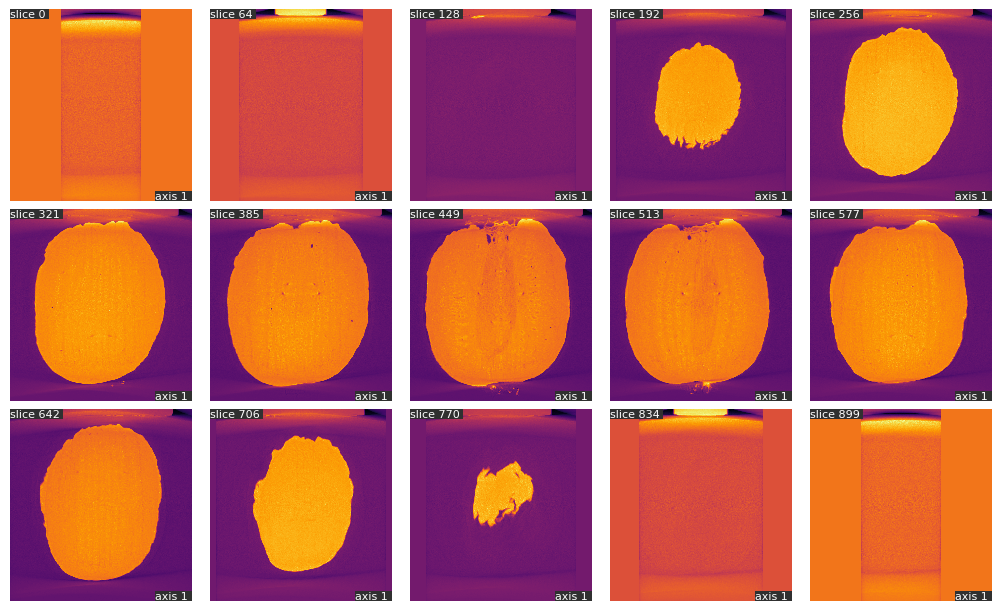

In [11]:
qim3d.viz.slices_grid(data, num_slices=15, slice_axis=1, color_map='inferno')

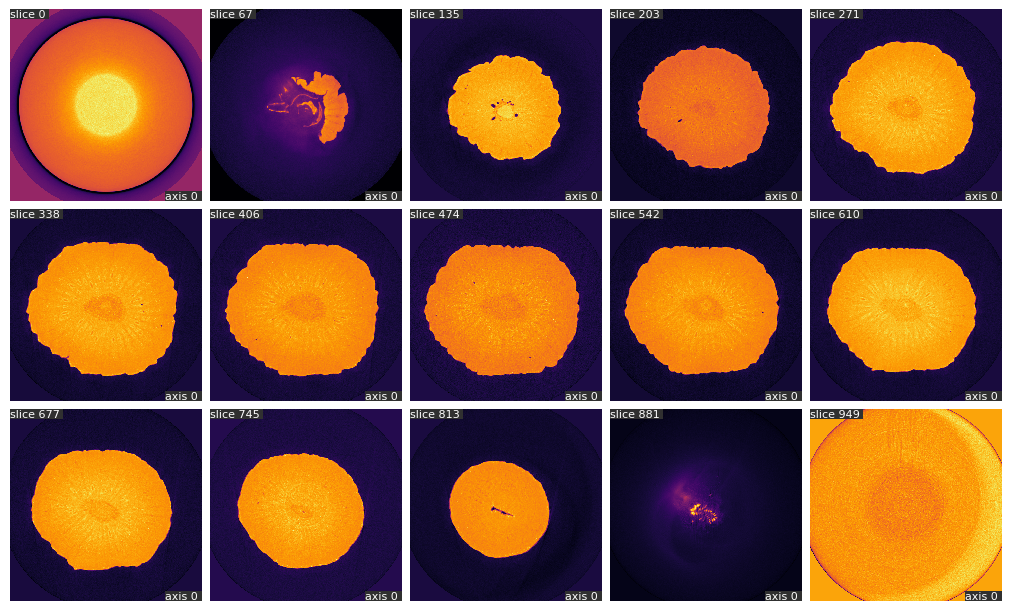

In [12]:
qim3d.viz.slices_grid(data, num_slices=15, slice_axis=0, color_map='inferno')

In [13]:
qim3d.viz.line_profile(data)

In [14]:
qim3d.viz.threshold(data)

In [15]:
qim3d.viz.volumetric(data_downsampled_0_25, vmin=10)

Output()

In [16]:
data_filtered_gaussian = qim3d.filters.gaussian(data_downsampled_0_5, sigma=2, dask=True)

In [17]:
qim3d.viz.slicer_orthogonal(data_filtered_gaussian, color_map='inferno')

In [18]:
data_filtered_median = qim3d.filters.median(data_downsampled_0_25, size=1, dask=True)

In [19]:
qim3d.viz.slicer_orthogonal(data_filtered_median, color_map='inferno')

### Segmentation

In [20]:
qim3d.viz.threshold(data_downsampled_0_5)

In [21]:
data_segmented = data_downsampled_0_5 > 45

In [22]:
qim3d.viz.slicer_orthogonal(data_segmented.astype(float))

In [23]:
data_segmented_cropped = data_segmented.copy()[100:-65, :, :]

In [24]:
qim3d.viz.slicer_orthogonal(data_segmented_cropped.astype(float))

In [25]:
data_segmented_filtered = qim3d.filters.median(data_segmented_cropped, size=3, dask=True)

In [26]:
qim3d.viz.slicer_orthogonal(data_segmented_filtered)

In [27]:
labeled_volume, num_labels = qim3d.segmentation.watershed(data_segmented_filtered, min_distance=10)
cmap = qim3d.viz.colormaps.segmentation(num_labels)

Total number of objects found: 546


The notebook segments 546 objects. The intention was to count the number of seeds, which lie between 500 and 2000 in an average kiwi fruit. The result can be finetuned but the capabilities are adequately showcased here.

In [28]:
qim3d.viz.slicer_orthogonal(labeled_volume, color_map=cmap)

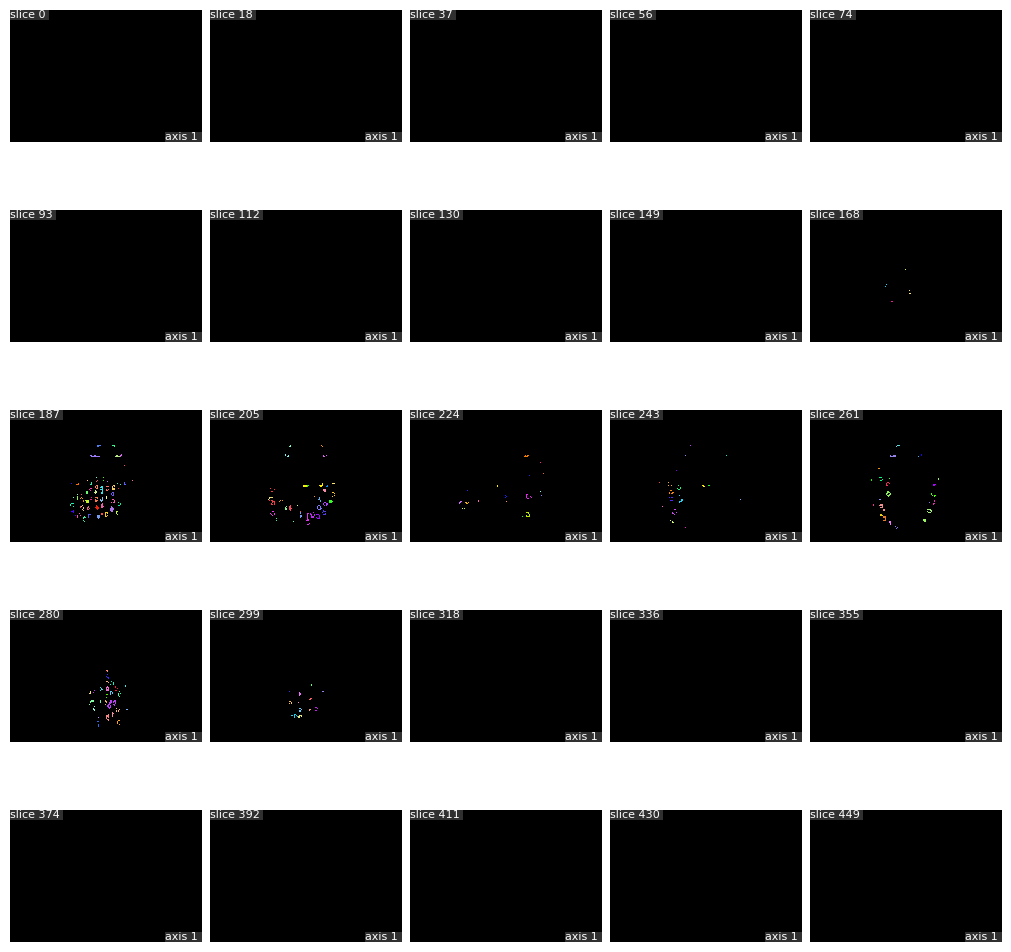

In [29]:
qim3d.viz.slices_grid(labeled_volume, slice_axis=1, num_slices=25, color_map=cmap)